<h3>Fitness tracker data analysis<h3>

<b>1. Importing required Libraries<b>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<b>2. Data Reading</b>

In [5]:
# Read the Fitness Tracker Dataset
data = pd.read_csv("fitness_data.csv")

# Display the first 5 rows of the dataset
# To check if the dataset is proper
print("First 5 rows of the dataset:")
print(data.head())

First 5 rows of the dataset:
           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  1503960366    4/12/2016       13162           8.50             8.50   
1  1503960366    4/13/2016       10735           6.97             6.97   
2  1503960366    4/14/2016       10460           6.74             6.74   
3  1503960366    4/15/2016        9762           6.28             6.28   
4  1503960366    4/16/2016       12669           8.16             8.16   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                1.88                      0.55   
1                       0.0                1.57                      0.69   
2                       0.0                2.44                      0.40   
3                       0.0                2.14                      1.26   
4                       0.0                2.71                      0.41   

   LightActiveDistance  SedentaryActiveDistance  VeryActiveMinu

<b>3. Data Cleaning</b>

In [6]:
# Convert ActivityDate column to datetime format to avoid syntax error
data['ActivityDate'] = pd.to_datetime(data['ActivityDate'])

# Fill missing values with 0
data.fillna(0, inplace=True)

# Remove duplicate rows
data.drop_duplicates(inplace=True)

# Display dataset information
print("\nDataset Information:")
print(data.info())

# Descriptive statistics
print("\nDescriptive Statistics:")
print(data.describe())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[ns]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  

<b>4. Visualization</b>
<p>1. Daily Step Count Distribution<p>

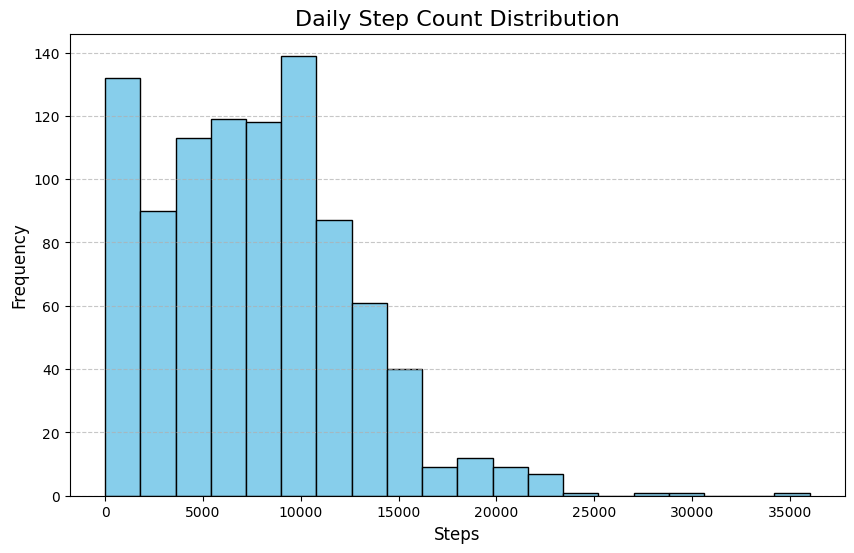

In [7]:
# Histogram for Daily Step Count
plt.figure(figsize=(10, 6))
plt.hist(data['TotalSteps'], bins=20, color='skyblue', edgecolor='black')
plt.title('Daily Step Count Distribution', fontsize=16)
plt.xlabel('Steps', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<p>2. Calories Burned Over Time<p>

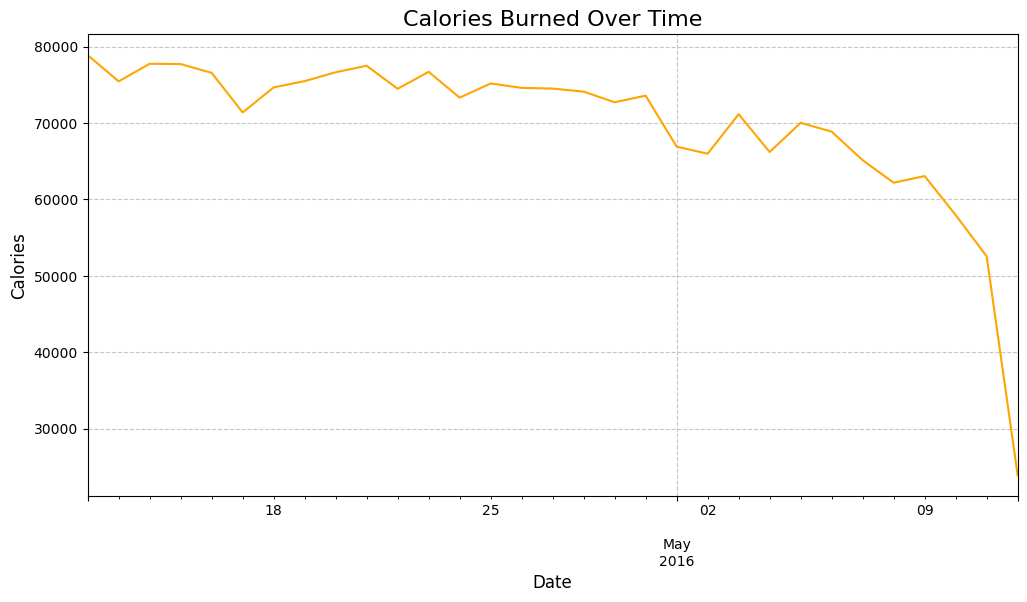

In [8]:
# Line chart for Calories Burned Over Time
calories_over_time = data.groupby('ActivityDate')['Calories'].sum()
plt.figure(figsize=(12, 6))
calories_over_time.plot(kind='line', color='orange')
plt.title('Calories Burned Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Calories', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

<p>3. Correlation Between Steps and Calories<p>

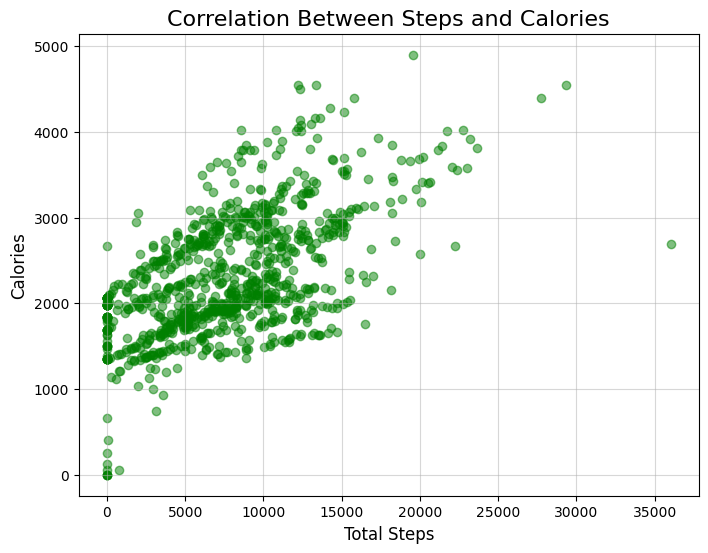

In [9]:
# Scatter plot for correlation between Total Steps and Calories
plt.figure(figsize=(8, 6))
plt.scatter(data['TotalSteps'], data['Calories'], color='green', alpha=0.5)
plt.title('Correlation Between Steps and Calories', fontsize=16)
plt.xlabel('Total Steps', fontsize=12)
plt.ylabel('Calories', fontsize=12)
plt.grid(alpha=0.5)
plt.show()

<p>4. Average Steps by Day of the Week</p>

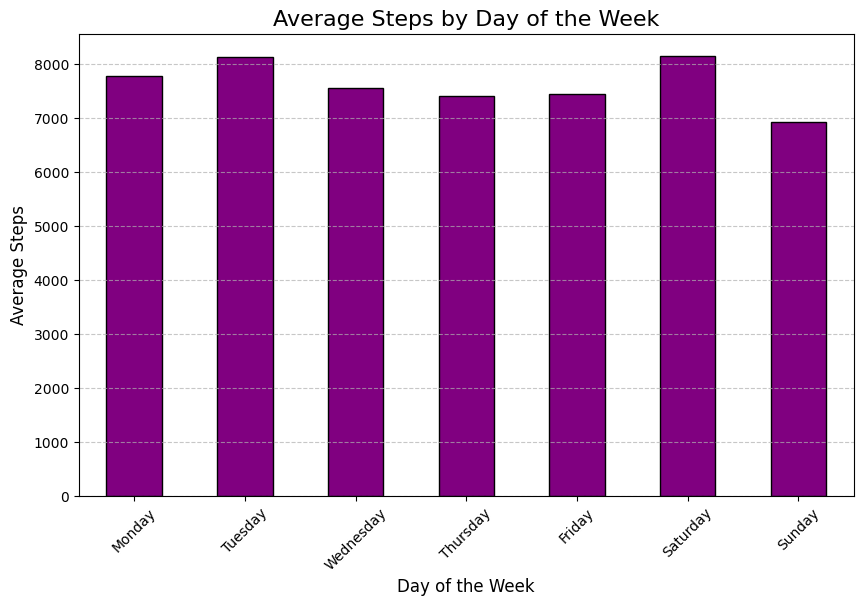

In [10]:
# Add a column for the day of the week
data['DayOfWeek'] = data['ActivityDate'].dt.day_name()

# Calculate average steps for each day
avg_steps_by_day = data.groupby('DayOfWeek')['TotalSteps'].mean()

# Sort days of the week for better visualization
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_steps_by_day = avg_steps_by_day.reindex(days_order)

# Bar chart for Average Steps by Day of the Week
plt.figure(figsize=(10, 6))
avg_steps_by_day.plot(kind='bar', color='purple', edgecolor='black')
plt.title('Average Steps by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Steps', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<p>5. Steps and Calories by Activity Intensity</p>

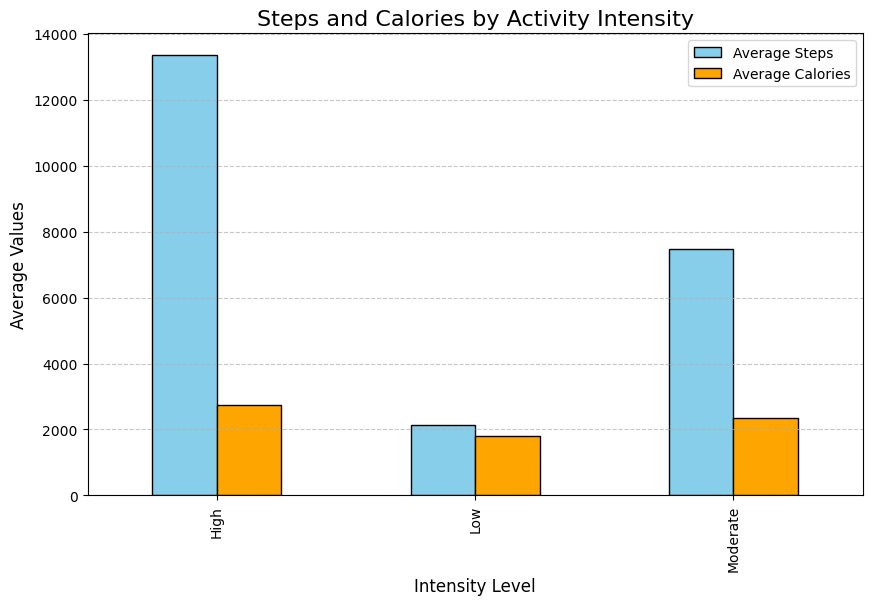

In [11]:
# Categorize steps into activity intensity levels
def intensity_category(steps):
    if steps < 5000:
        return 'Low'
    elif steps < 10000:
        return 'Moderate'
    else:
        return 'High'

data['Intensity'] = data['TotalSteps'].apply(intensity_category)

# Calculate average steps and calories by intensity
intensity_data = data.groupby('Intensity')[['TotalSteps', 'Calories']].mean()

# Dual bar chart for Steps and Calories by Activity Intensity
intensity_data.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'orange'], edgecolor='black')
plt.title('Steps and Calories by Activity Intensity', fontsize=16)
plt.xlabel('Intensity Level', fontsize=12)
plt.ylabel('Average Values', fontsize=12)
plt.legend(['Average Steps', 'Average Calories'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<p>6. Steps vs. Calories Density Plot</p>

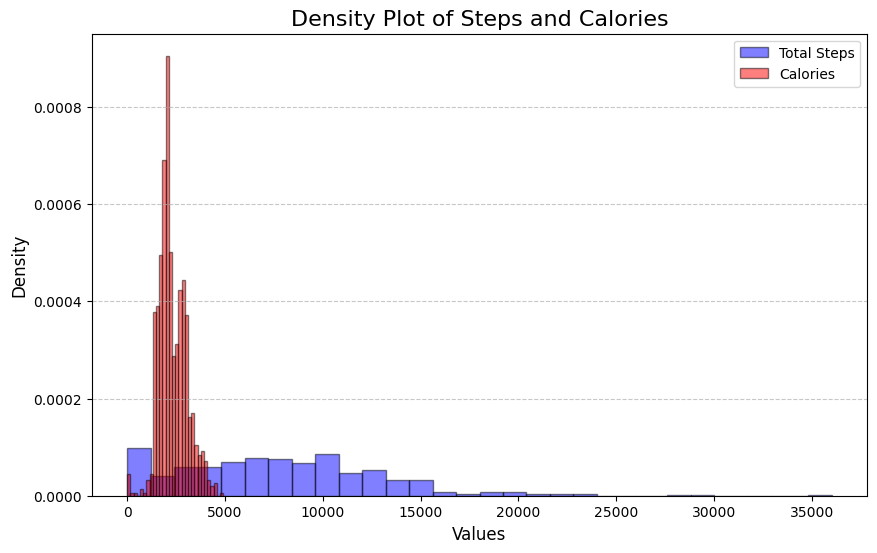

In [12]:
# Density plot for Steps and Calories
plt.figure(figsize=(10, 6))
plt.hist(data['TotalSteps'], bins=30, alpha=0.5, label='Total Steps', color='blue', edgecolor='black', density=True)
plt.hist(data['Calories'], bins=30, alpha=0.5, label='Calories', color='red', edgecolor='black', density=True)
plt.title('Density Plot of Steps and Calories', fontsize=16)
plt.xlabel('Values', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<b>5. Conclusion</b><p>From analyzing the fitness tracker data, I learned a lot about user activity trends and patterns. The average daily steps and calories burned gave a clear picture of how active users are on a daily basis. I noticed that higher activity levels, like taking more than 10,000 steps, are linked to burning more calories, which makes sense since being more active uses more energy. By grouping steps into categories like low, moderate, and high intensity, it became clear that some users might need to work on moving more to reach healthier activity levels. It was also interesting to see that activity tends to peak on weekends, which means people might be less active during weekdays. These patterns can help users plan their fitness routines better and focus on staying active throughout the week. Overall, this analysis highlights some useful insights that can be used to improve health and fitness goals.<p>